# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 59     |  |
| :-------------|:-------------|
| Student Ole Doekes| 6489028 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Ole']

## Opdracht 1: Planning.

Ik haal hem in, dus ik doe het in mijn eigen tijd.

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [59]
<img src="Fotoopstelling.png" width="800">

Factor (a) is: 0.0333
De afwijking/offset (b) is: 1.0327


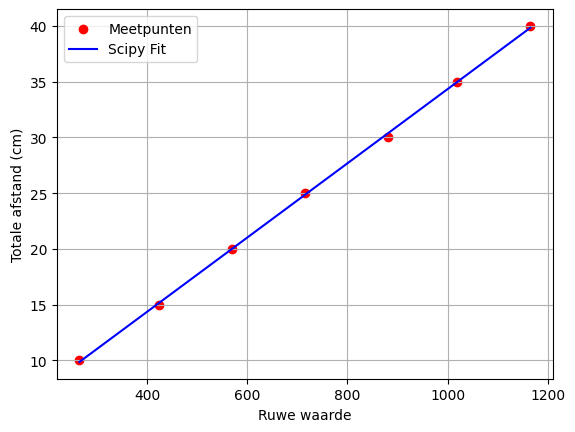

In [3]:
from scipy.optimize import curve_fit

#Data
ruwe_waarden = [265, 423, 570, 715, 880, 1019, 1165]
totale_afstanden = [10, 15, 20, 25, 30, 35, 40]

#Functie voor een rechte lijn
def lineair_verband(x, a, b):
    return a * x + b

#Gebruik curve_fit om de beste 'a' en 'b' te vinden
popt, pcov = curve_fit(lineair_verband, ruwe_waarden, totale_afstanden)

a_fit = popt[0]
b_fit = popt[1]

print(f"Factor (a) is: {a_fit:.4f}")
print(f"De afwijking/offset (b) is: {b_fit:.4f}")

#Plotten
plt.scatter(ruwe_waarden, totale_afstanden, label='Meetpunten', color='red')

#Maak lijn
verwachte_y = [lineair_verband(x, a_fit, b_fit) for x in ruwe_waarden]
plt.plot(ruwe_waarden, verwachte_y, label='Scipy Fit', color='blue')

plt.xlabel('Ruwe waarde')
plt.ylabel('Totale afstand (cm)')
plt.legend()
plt.grid(True)
plt.show()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  41.2
1   0  30   0  20  41.5
2   0  10   0  20  49.5
3  40   0  30   0  41.2
4  30   0  20   0  41.5
5  10   0  20   0  51.9
6  10   0   0  10  44.2


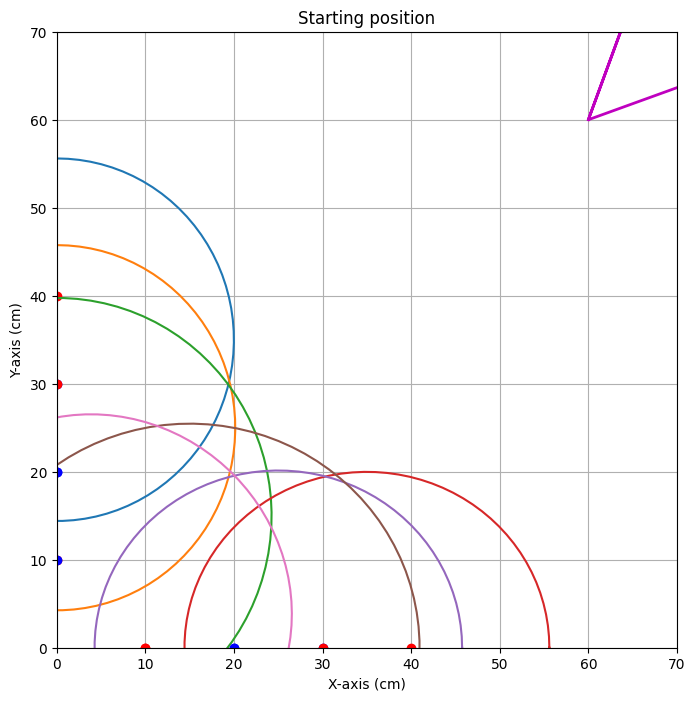


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=105.166


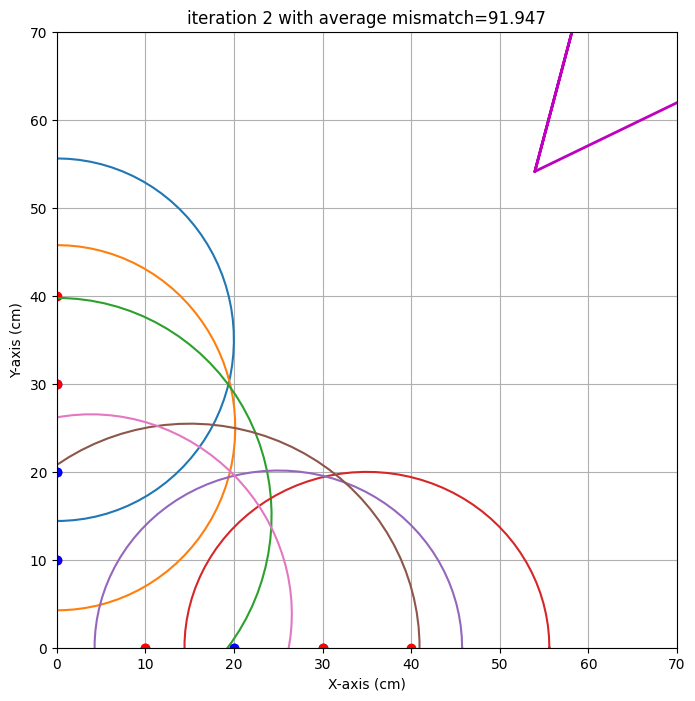

end iteration 2 with average mismatch=91.947


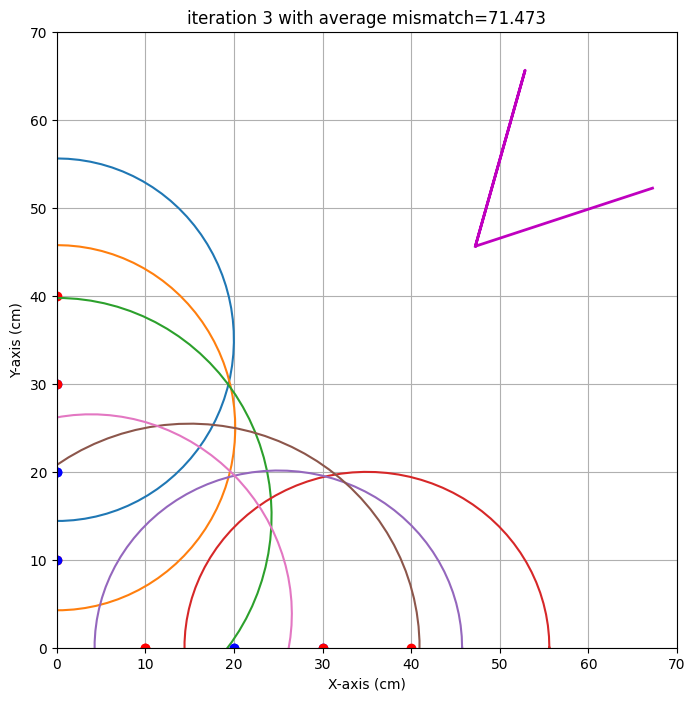

end iteration 3 with average mismatch=71.473


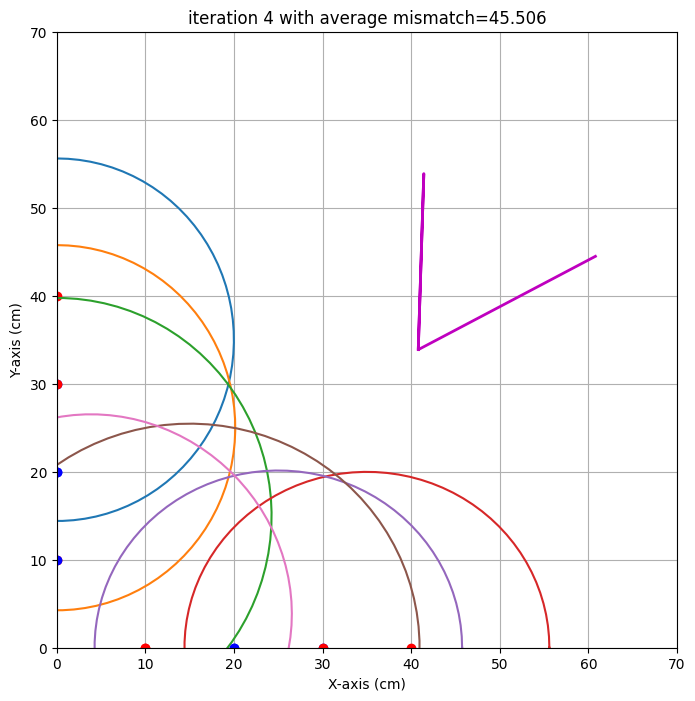

end iteration 4 with average mismatch=45.506


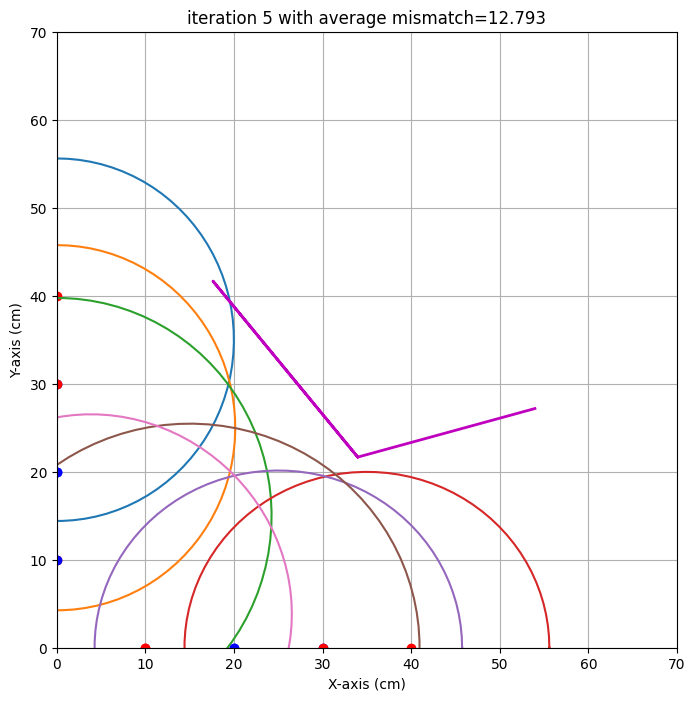

end iteration 5 with average mismatch=12.793


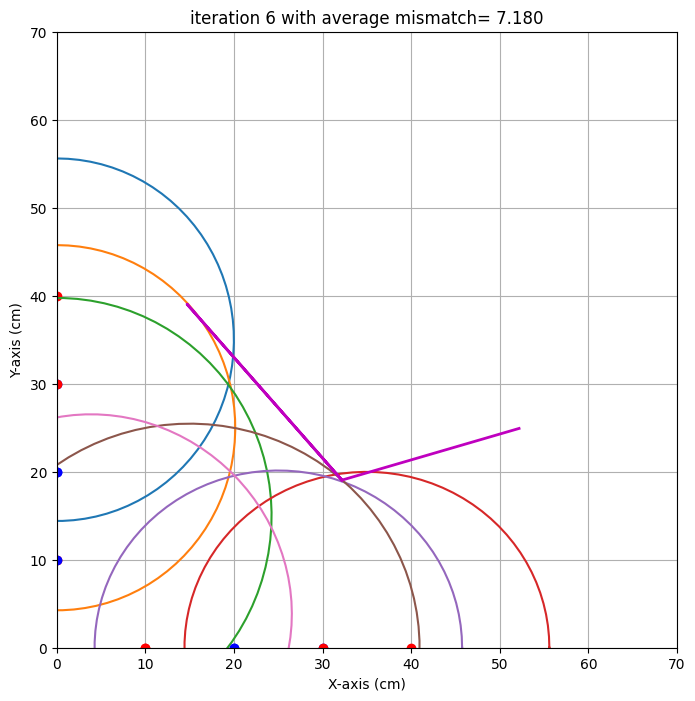

end iteration 6 with average mismatch= 7.180
end iteration 7 with average mismatch= 6.669


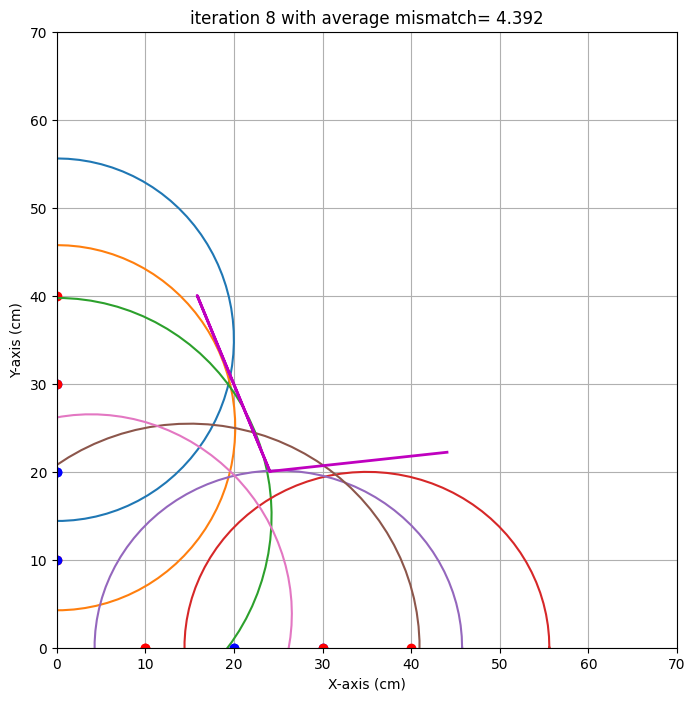

end iteration 8 with average mismatch= 4.392


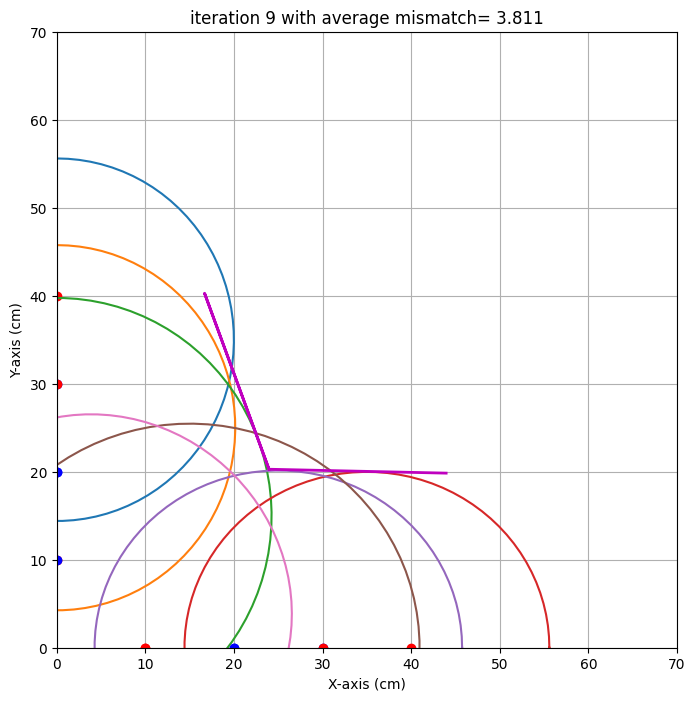

end iteration 9 with average mismatch= 3.811
end iteration 10 with average mismatch= 3.800
end iteration 11 with average mismatch= 3.793
end iteration 12 with average mismatch= 3.792
end iteration 13 with average mismatch= 3.791
end iteration 14 with average mismatch= 3.791
end iteration 15 with average mismatch= 3.791
end iteration 16 with average mismatch= 3.791
end iteration 17 with average mismatch= 3.791
end iteration 18 with average mismatch= 3.727
end iteration 19 with average mismatch= 3.727
end iteration 20 with average mismatch= 3.727
end iteration 21 with average mismatch= 3.656
end iteration 22 with average mismatch= 3.598
end iteration 23 with average mismatch= 3.598
end iteration 24 with average mismatch= 3.598
end iteration 25 with average mismatch= 3.598
end iteration 26 with average mismatch= 3.569
end iteration 27 with average mismatch= 3.528
end iteration 28 with average mismatch= 3.528
end iteration 29 with average mismatch= 3.528
Last iteration, also determine unce

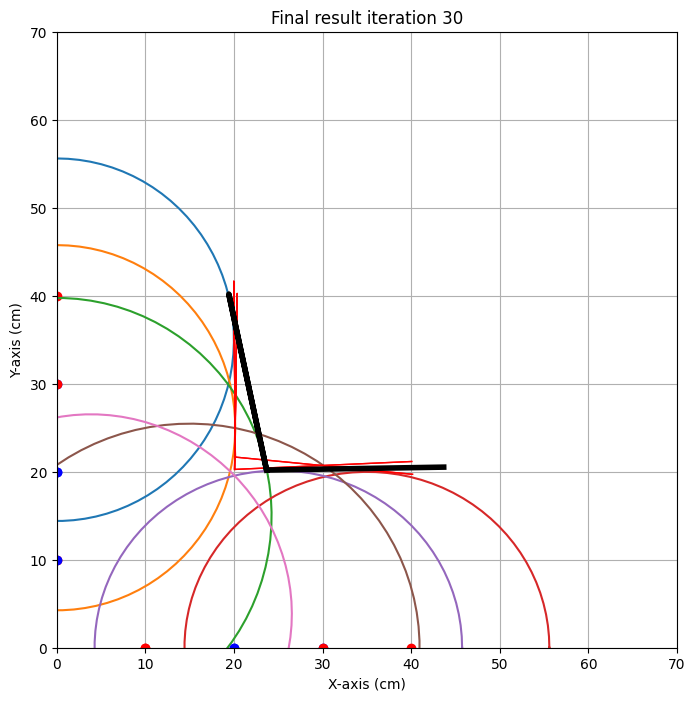

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41.2],
    [0,30,0,20,41.5],
    [0,10,0,20,49.5],
    [40,0,30,0,41.2],
    [30,0,20,0,41.5],
    [10,0,20,0,51.9],
    [10,0,0,10,44.2]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 23.7 cm met een standaardafwijking van 3.6 cm 
y0: 20.2 cm met een standaardafwijking van 1.5 cm 
alpha: 1.0 graden met een standaardafwijking van 6.5 graad 
beta: -12.0 graden met een standaardafwijking van 12.9 graad 



## Opdracht 5: Iteratie 0

#### algoritme Ole
Voeg een foto in van het algoritme van het eerste groepslid
<img src="tweedfoto.png" width="400">


## Opdracht 6: Test iteratie 0.

In [6]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':30 ,
           'y0':30 ,
           'alpha' : 10 ,
           'beta' : 55  
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Ole' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,0,10,0, 81.6],
    [0,0,10,0, 81.4],
    [40,0,30,0, 64.2],
    [50,0,40,0, 40.4],
    [50,0,40,0, 40.5],
    [60,0,50,0, 67.7],
    [10,0,0,0, 76.9],
    [10,0,0,0, 76.3],
    [10,0,20,0, 62.8],
    [20,0,30,0, 52.4],
    [20,0,30,0, 52.3],
    ]),
      }


## Opdracht 7: Evaluatie.

Ole
Running the imaging algorithm with the following data:
    xs  ys  xr  yr     R
0    0   0  10   0  81.6
1    0   0  10   0  81.4
2   40   0  30   0  64.2
3   50   0  40   0  40.4
4   50   0  40   0  40.5
5   60   0  50   0  67.7
6   10   0   0   0  76.9
7   10   0   0   0  76.3
8   10   0  20   0  62.8
9   20   0  30   0  52.4
10  20   0  30   0  52.3


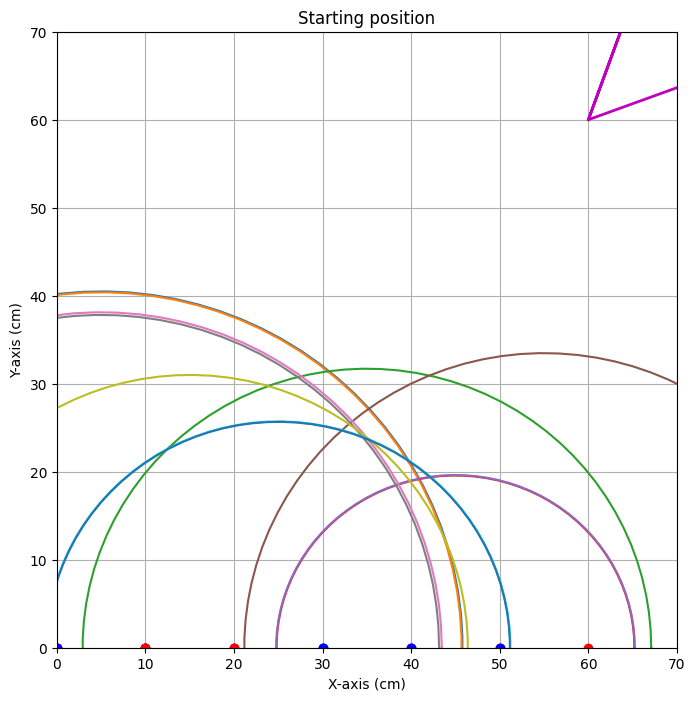


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=88.675


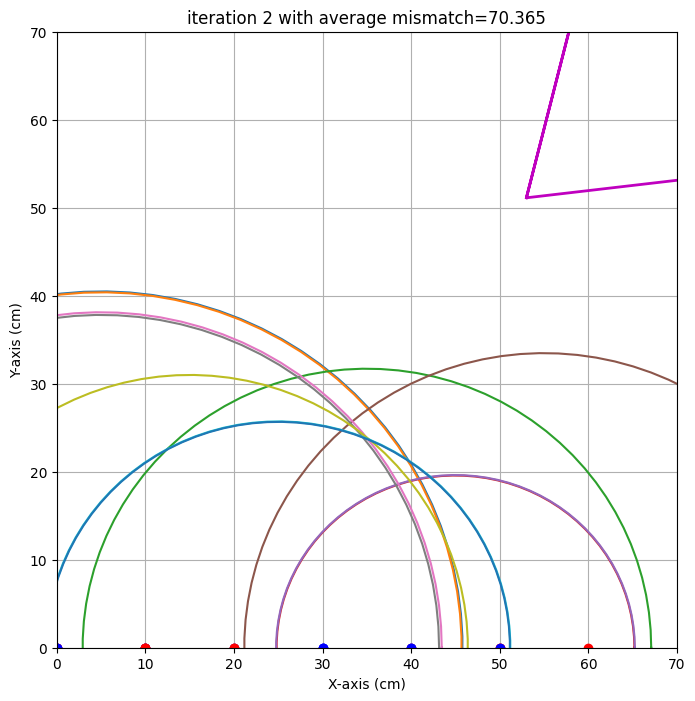

end iteration 2 with average mismatch=70.365


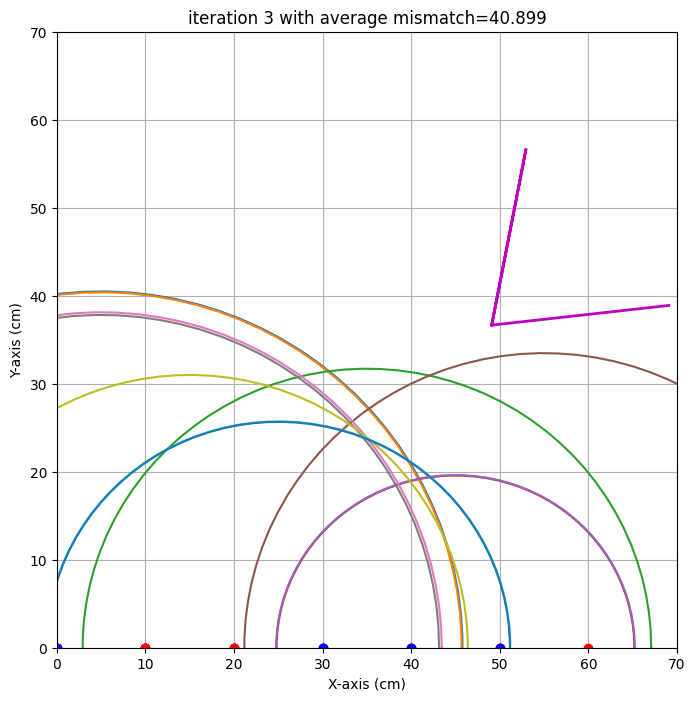

end iteration 3 with average mismatch=40.899


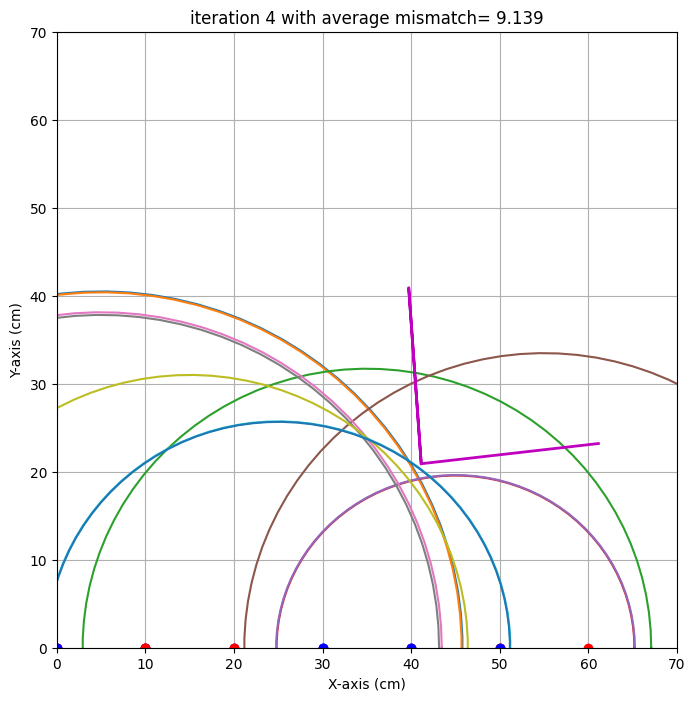

end iteration 4 with average mismatch= 9.139


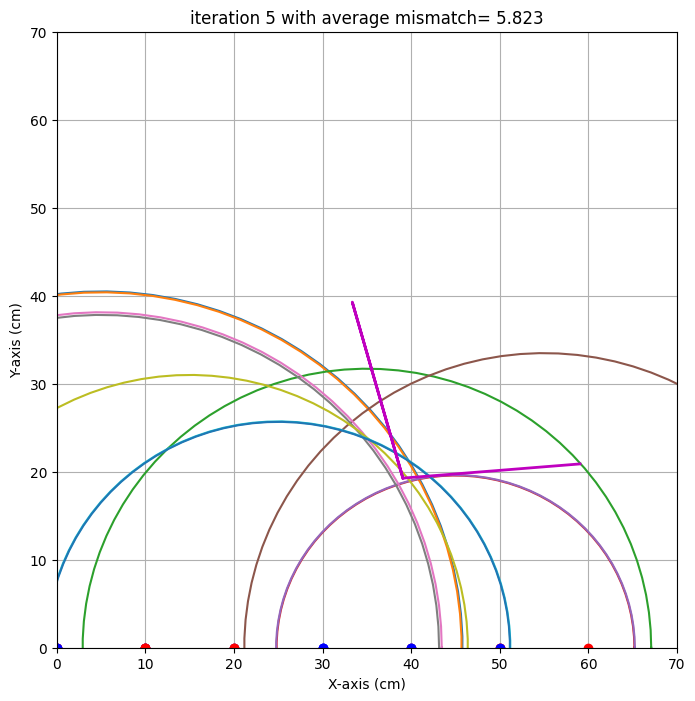

end iteration 5 with average mismatch= 5.823
end iteration 6 with average mismatch= 5.807


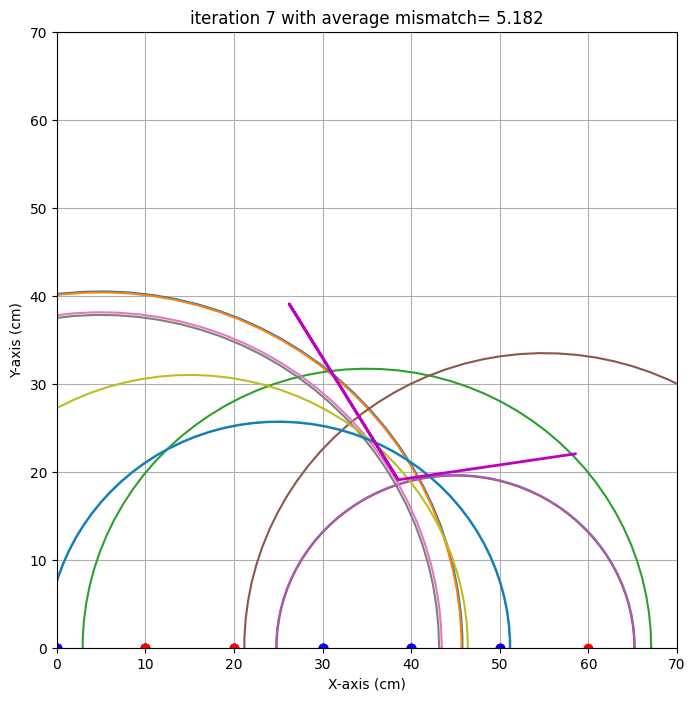

end iteration 7 with average mismatch= 5.182
end iteration 8 with average mismatch= 5.024
end iteration 9 with average mismatch= 4.901
end iteration 10 with average mismatch= 4.606
end iteration 11 with average mismatch= 4.583
end iteration 12 with average mismatch= 4.583
end iteration 13 with average mismatch= 4.583
end iteration 14 with average mismatch= 4.461
end iteration 15 with average mismatch= 4.461
end iteration 16 with average mismatch= 4.397
end iteration 17 with average mismatch= 4.397
end iteration 18 with average mismatch= 4.397
end iteration 19 with average mismatch= 4.397
end iteration 20 with average mismatch= 4.397
end iteration 21 with average mismatch= 4.397
end iteration 22 with average mismatch= 4.397
end iteration 23 with average mismatch= 4.397
end iteration 24 with average mismatch= 4.397
end iteration 25 with average mismatch= 4.397
end iteration 26 with average mismatch= 4.397
end iteration 27 with average mismatch= 4.397
end iteration 28 with average mismatc

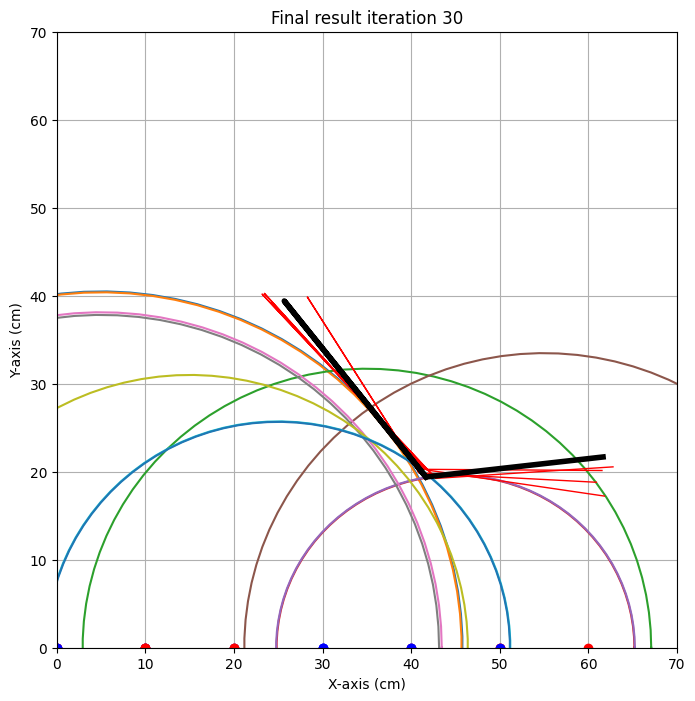

{'alpha': np.float64(6.480335336239477), 'alpha_eps': np.float64(14.886999887781037), 'beta': np.float64(-38.64456495044975), 'beta_eps': np.float64(6.356740106952209), 'x0': np.float64(41.66230407683785), 'x0_eps': np.float64(1.1229923984657049), 'y0': np.float64(19.40397308693745), 'y0_eps': np.float64(0.8676570439126898)}


In [7]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [8]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Ole 
x0 target is : 30.0. Gevonden waarde: 41.7 cm met een standaardafwijking van 1.1 cm 
y0 target is : 30.0. Gevonden waarde: 19.4 cm met een standaardafwijking van 0.9 cm 
alpha target is : 10.0. Gevonden waarde: 6.5 graden met een standaardafwijking van 14.9 graad 
beta target is : 55.0. Gevonden waarde: -38.6 graden met een standaardafwijking van 6.4 graad 



## Opdracht 8: Iteratie1+.21:38
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](piccaatje.png)


In [9]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

Locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  21   0  70.6
1  50   0  30   0  46.4
2  60   0  40   0  67.3
3  70   0  50   0  74.2
4  80   0  47   0  83.1
5   0  40   0  20  61.5
6   0  50   0  30  58.7
7   0  60   0  38  66.8


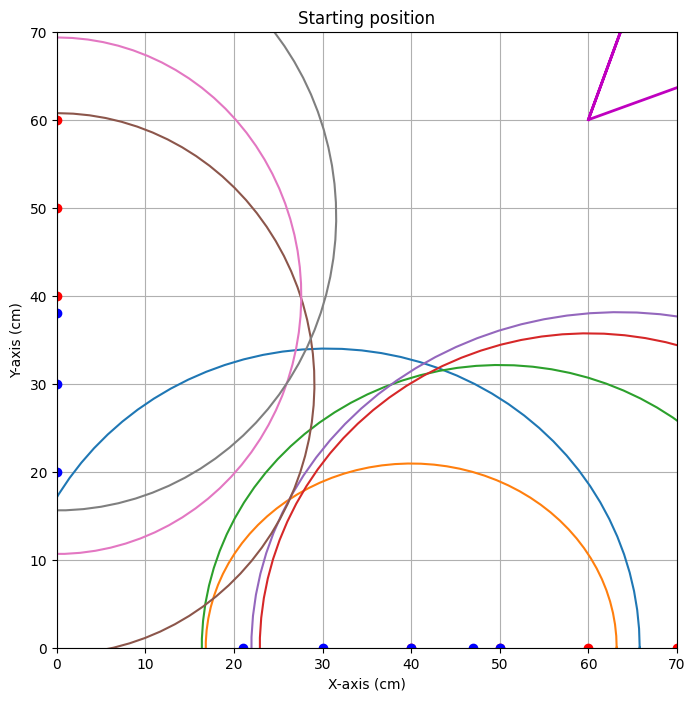


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.469


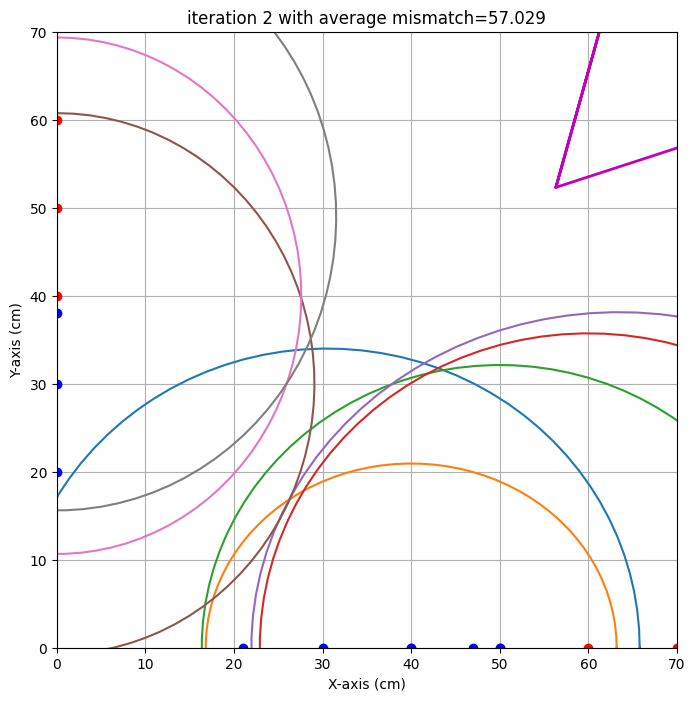

end iteration 2 with average mismatch=57.029


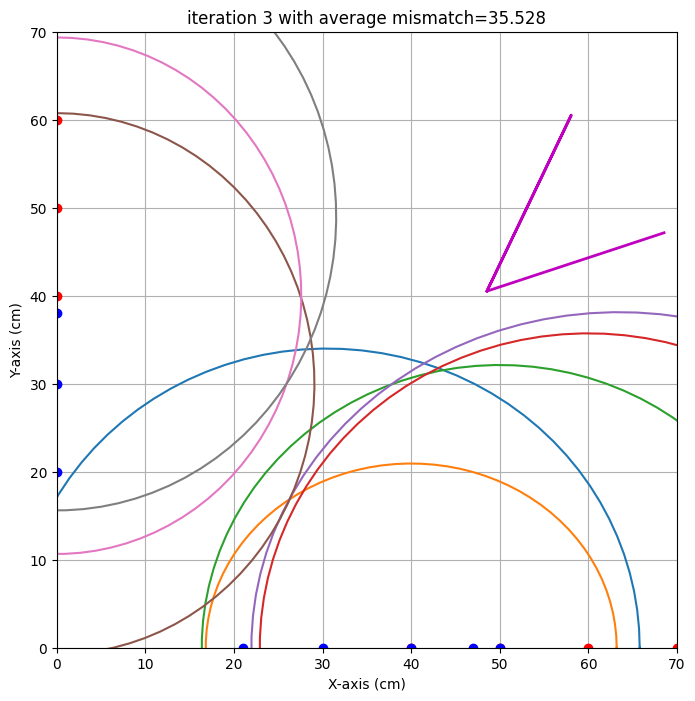

end iteration 3 with average mismatch=35.528


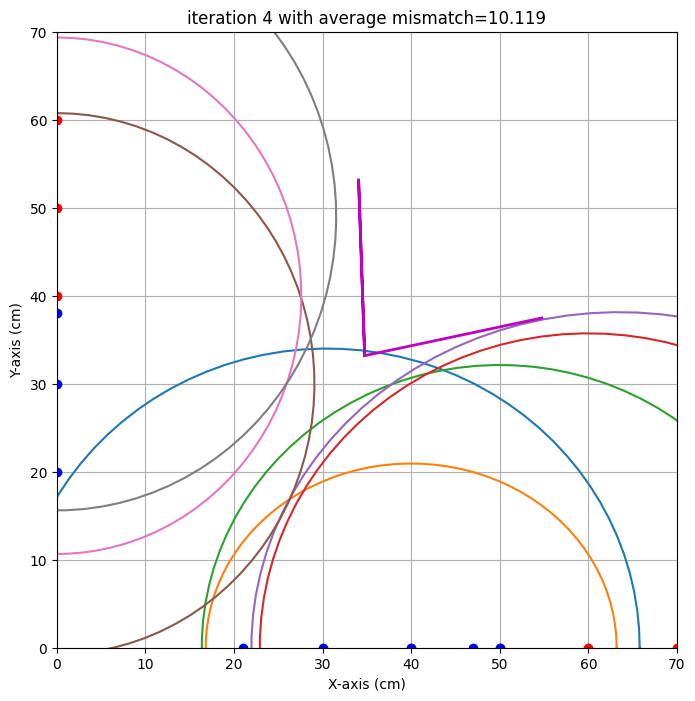

end iteration 4 with average mismatch=10.119


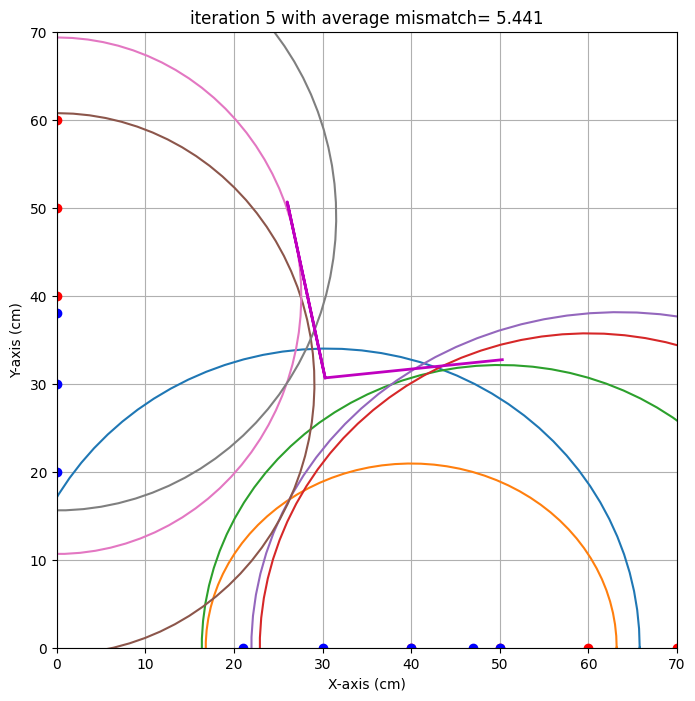

end iteration 5 with average mismatch= 5.441


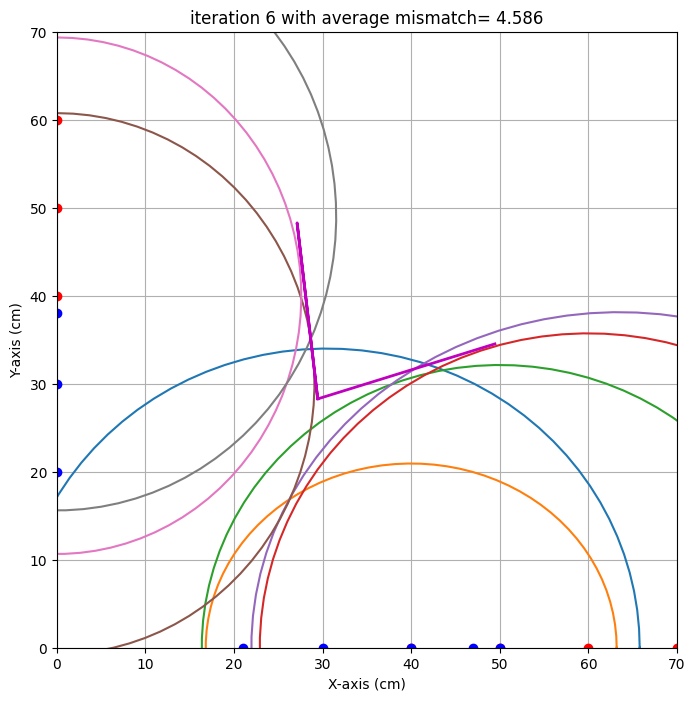

end iteration 6 with average mismatch= 4.586
end iteration 7 with average mismatch= 4.539
end iteration 8 with average mismatch= 4.506
end iteration 9 with average mismatch= 4.504
end iteration 10 with average mismatch= 4.503
end iteration 11 with average mismatch= 4.503
end iteration 12 with average mismatch= 4.377
end iteration 13 with average mismatch= 4.377
end iteration 14 with average mismatch= 4.377
end iteration 15 with average mismatch= 4.377
end iteration 16 with average mismatch= 4.377
end iteration 17 with average mismatch= 4.376
end iteration 18 with average mismatch= 4.376
end iteration 19 with average mismatch= 4.376
end iteration 20 with average mismatch= 4.376
end iteration 21 with average mismatch= 4.376
end iteration 22 with average mismatch= 4.376
end iteration 23 with average mismatch= 4.376
end iteration 24 with average mismatch= 4.376
end iteration 25 with average mismatch= 4.376
end iteration 26 with average mismatch= 4.376
end iteration 27 with average mismatch

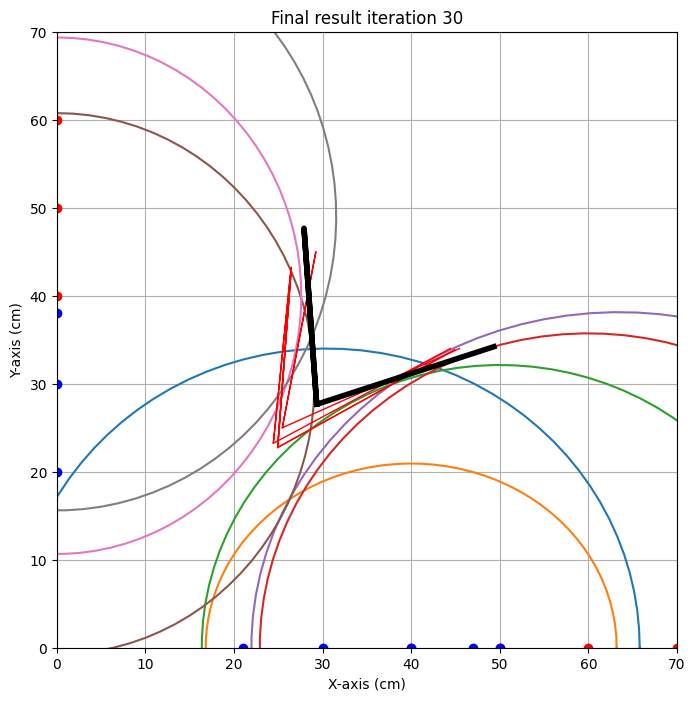

{'alpha': np.float64(18.120331822272455), 'alpha_eps': np.float64(10.9239426140145), 'beta': np.float64(-4.097811338943625), 'beta_eps': np.float64(14.827790143780845), 'x0': np.float64(29.33026065435816), 'x0_eps': np.float64(4.896229224231288), 'y0': np.float64(27.661556118429843), 'y0_eps': np.float64(4.910117795638719)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0   0  20   0  32.8
1  20   0   0   0  32.3
2  30   0  10   0  29.4
3  40   0  20   0  30.1
4  50   0  20   0  46.2
5   0  30  10   0  30.9
6   0  40   0  20  34.5
7   0  50   0  25  46.8


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


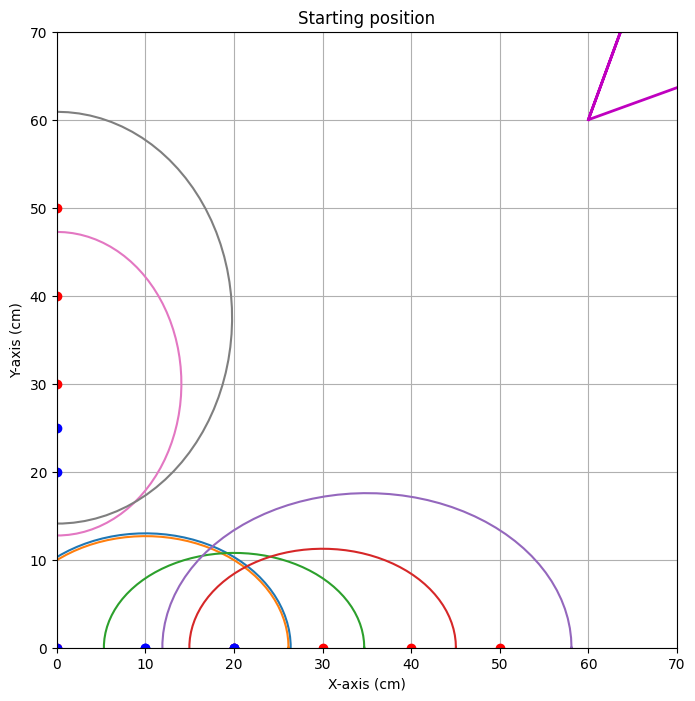


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=114.306
end iteration 2 with average mismatch=104.962


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


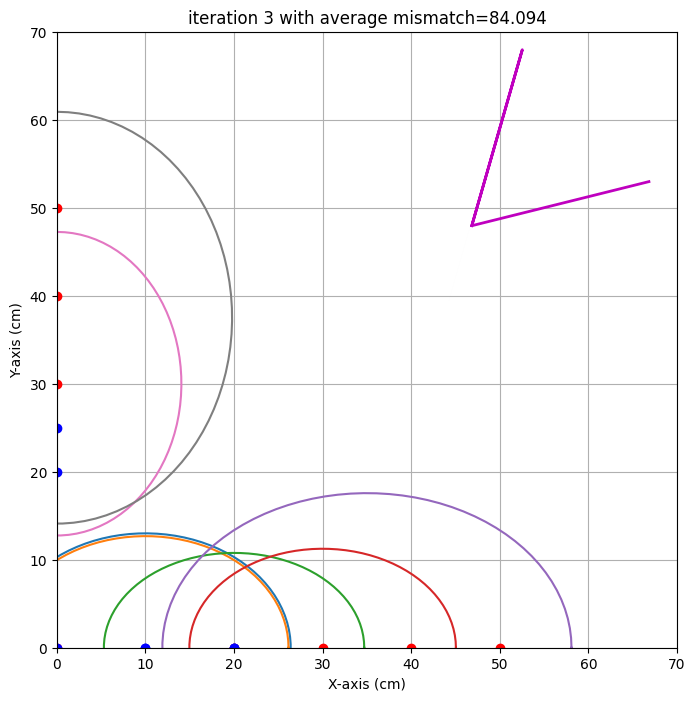

end iteration 3 with average mismatch=84.094


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


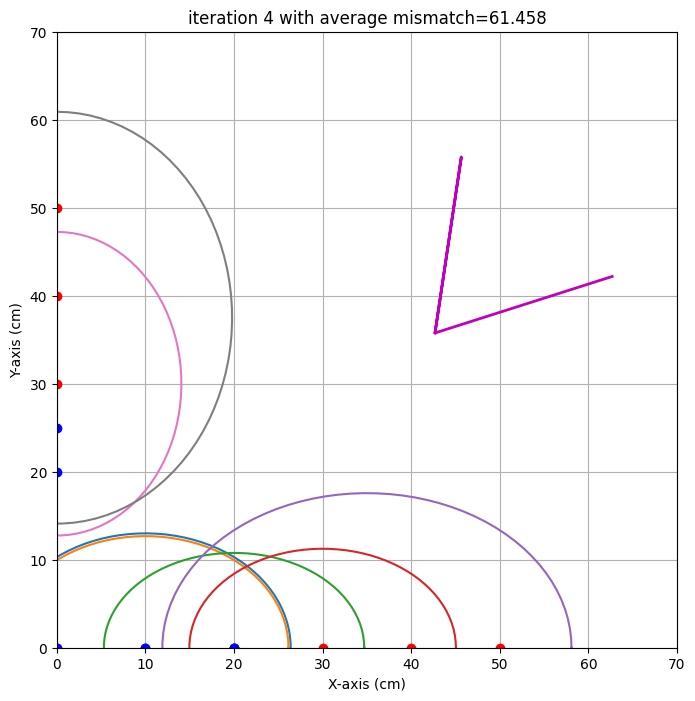

end iteration 4 with average mismatch=61.458


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


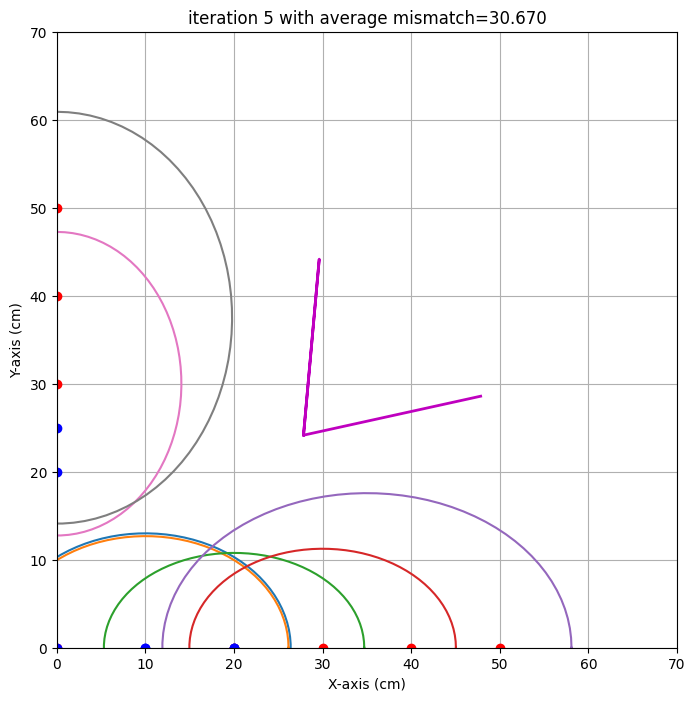

end iteration 5 with average mismatch=30.670


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


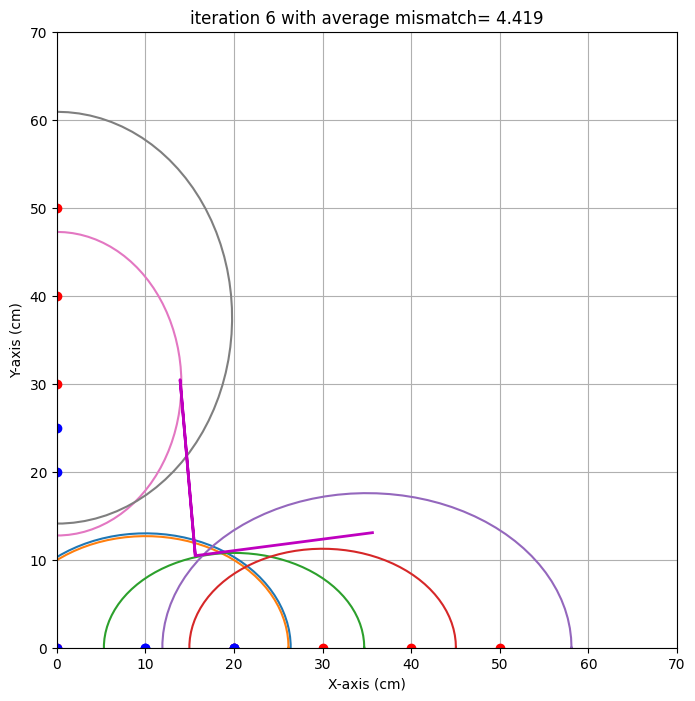

end iteration 6 with average mismatch= 4.419


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


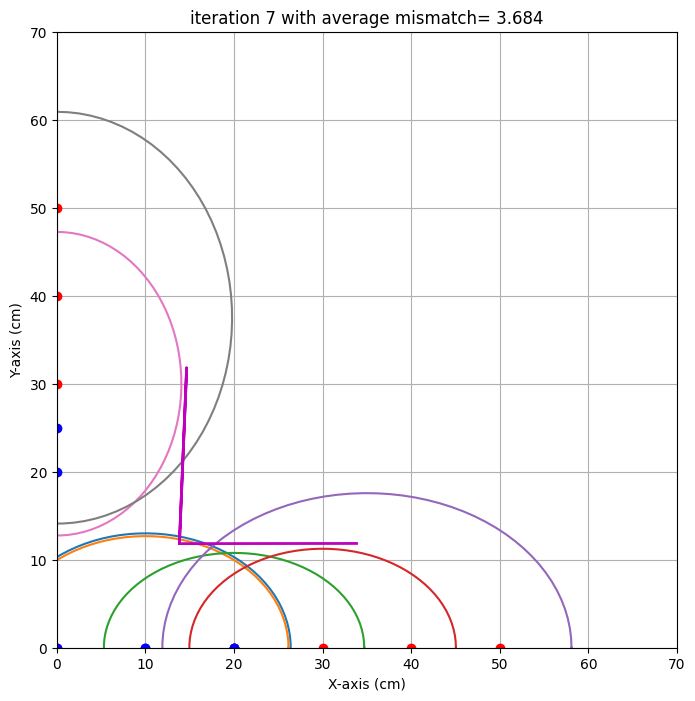

end iteration 7 with average mismatch= 3.684


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


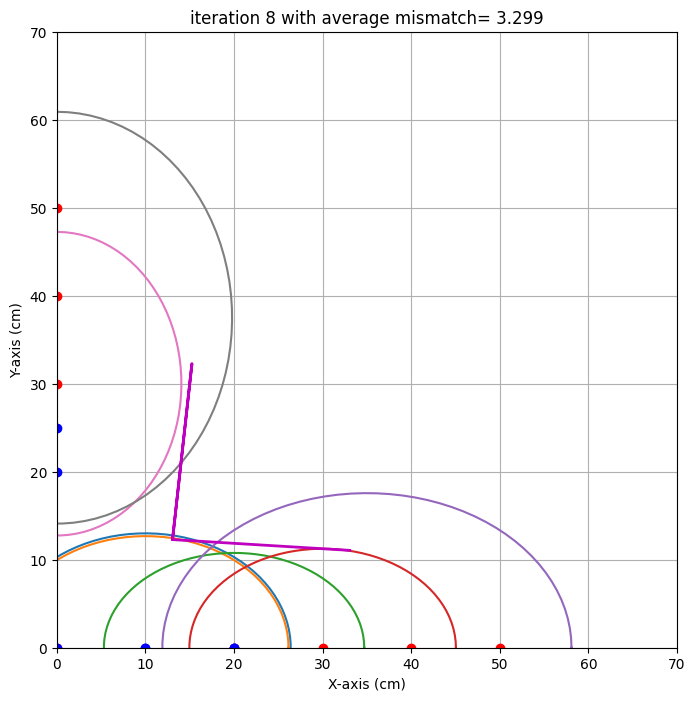

end iteration 8 with average mismatch= 3.299
end iteration 9 with average mismatch= 3.103


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


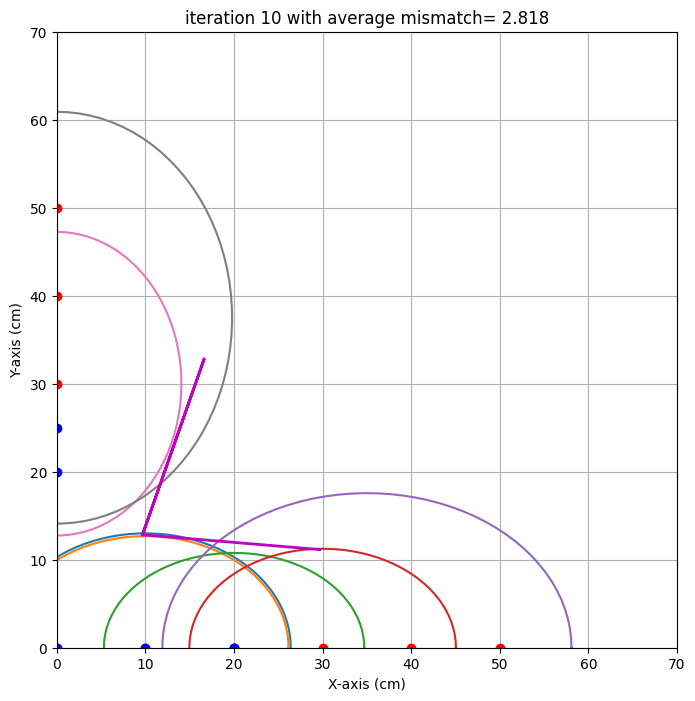

end iteration 10 with average mismatch= 2.818
end iteration 11 with average mismatch= 2.812
end iteration 12 with average mismatch= 2.768
end iteration 13 with average mismatch= 2.760
end iteration 14 with average mismatch= 2.757
end iteration 15 with average mismatch= 2.756
end iteration 16 with average mismatch= 2.756
end iteration 17 with average mismatch= 2.756
end iteration 18 with average mismatch= 2.756
end iteration 19 with average mismatch= 2.737
end iteration 20 with average mismatch= 2.737
end iteration 21 with average mismatch= 2.737
end iteration 22 with average mismatch= 2.737
end iteration 23 with average mismatch= 2.737
end iteration 24 with average mismatch= 2.737
end iteration 25 with average mismatch= 2.736
end iteration 26 with average mismatch= 2.736
end iteration 27 with average mismatch= 2.735
end iteration 28 with average mismatch= 2.733
end iteration 29 with average mismatch= 2.731
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


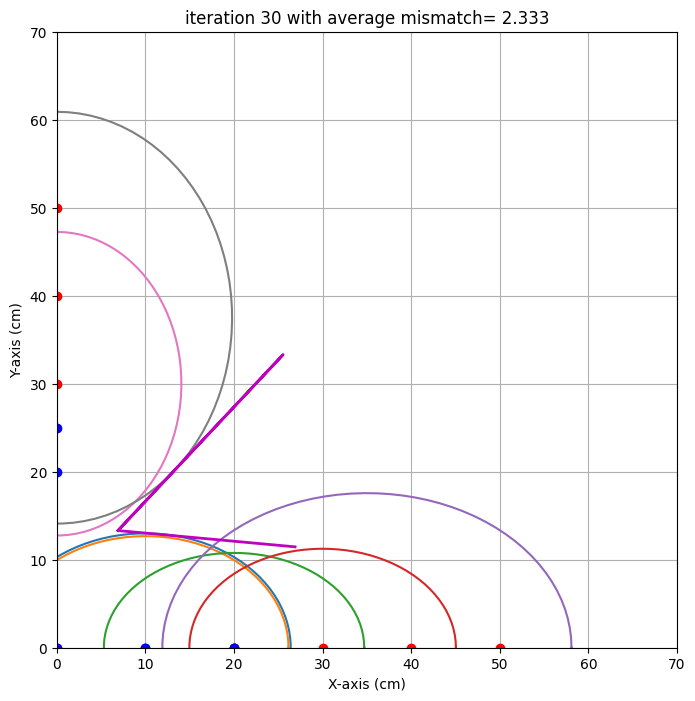

end iteration 30 with average mismatch= 2.333
###############################################################################
end of iteration  30
Best alpha=  -5.28 with uncertainty=   6.35
Best beta =  43.00 with uncertainty=  11.28
Best x0   =   6.89 with uncertainty=   2.40
Best y0   =  13.31 with uncertainty=   0.62
###############################################################################


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


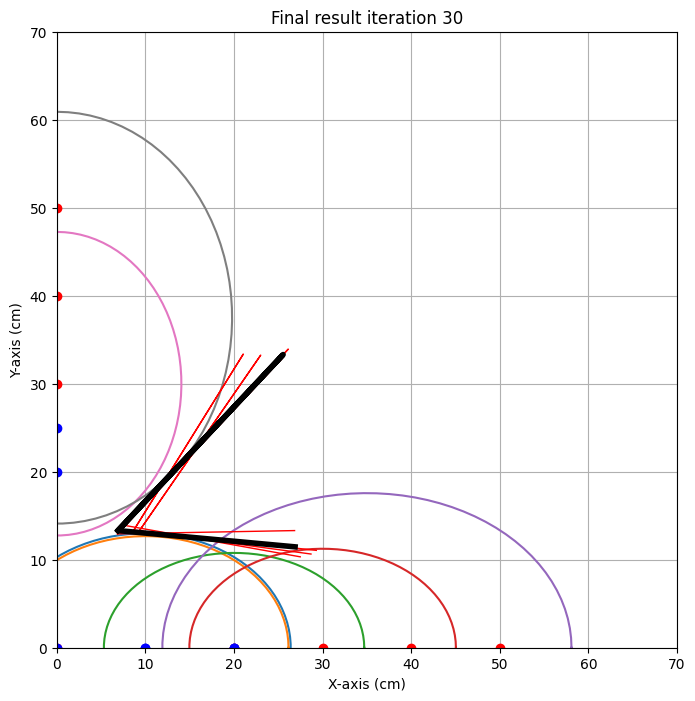

{'alpha': np.float64(-5.284649712542318), 'alpha_eps': np.float64(6.345826649107257), 'beta': np.float64(43.0), 'beta_eps': np.float64(11.284933310690043), 'x0': np.float64(6.890719384284722), 'x0_eps': np.float64(2.396148827641346), 'y0': np.float64(13.312757347669836), 'y0_eps': np.float64(0.6202852834877888)}
Locatie 1 
x0 target is : 30.0. Gevonden waarde: 29.3 cm met een standaardafwijking van 4.9 cm 
y0 target is : 30.0. Gevonden waarde: 27.7 cm met een standaardafwijking van 4.9 cm 
alpha target is : 10.0. Gevonden waarde: 18.1 graden met een standaardafwijking van 10.9 graad 
beta target is : 10.0. Gevonden waarde: -4.1 graden met een standaardafwijking van 14.8 graad 

locatie 2 
x0 target is : 10.0. Gevonden waarde: 6.9 cm met een standaardafwijking van 2.4 cm 
y0 target is : 10.0. Gevonden waarde: 13.3 cm met een standaardafwijking van 0.6 cm 
alpha target is : 2.0. Gevonden waarde: -5.3 graden met een standaardafwijking van 6.3 graad 
beta target is : 12.0. Gevonden waarde:

In [10]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {
    'Locatie 1': {
        'x0': 30,
        'y0': 30,
        'alpha': 10,
        'beta': 10
    },
    'locatie 2': {
        'x0': 10,
        'y0': 10,
        'alpha': 2,
        'beta': 12
    }
}

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'Locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,21,0, 70.6],
    [50,0,30,0, 46.4],
    [60,0,40,0, 67.3],
    [70,0,50,0, 74.2],
    [80,0,47,0, 83.1],
    [0,40,0,20, 61.5],
    [0,50,0,30, 58.7],
    [0,60,0,38, 66.8],
    ]),
    'locatie 2' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,0,20,0, 32.8],
    [20,0,0,0, 32.3],
    [30,0,10,0, 29.4],
    [40,0,20,0, 30.1],
    [50,0,20,0, 46.2],
    [0,30,10,0, 30.9],
    [0,40,0,20, 34.5],
    [0,50,0,25, 46.8],
    ]),
}                      
                       
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                       
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA, ik heb het al twee getest en heb heir geen TA op dit moment, dus hopelijk is wat ik hierboven heb gedaan voldoende.

In [11]:
'''

# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))
'''

'\n\n# Voeg hier je meetgegevens van de uiteindelijke test in:\n\n# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven\n# door jullie TA\ntargets = {\'test locatie\':{\n                    \'x0\':  # zelf aanvullen,\n                    \'y0\':  # zelf aanvullen,\n                    \'alpha\' :  # zelf aanvullen,\n                    \'beta\' :  # zelf aanvullen\n                          }\n            }\n\n\n# Vul onderstaande matrixen aan met je gemeten meetgegevens.\n\ndataFinalCheck ={\'test locatie\' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[\n                    # zelf aanvullen\n                    ])\n                }\n\n# Hier runnen we het imaging algoritme:\nresultaat = dict()\n\nfor locatie in targets:\n    print(locatie)\n    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])\n    print(resultaat[locatie])\n\n\n# Run deze cel om jullie resultaten naast elkaar te kunnen zien.\nfor locatie in targets:\n    txt 

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tweedfoto.png "Title")

Figuur: ![Alt](piccaatje.png "Title")

Aan het begin heb ik minder simulaties gedaan en stonden de sensoren verder van elkaar vandaan, hierdoor had ik eigenlijk niet een hele hoge accuratie en moest er iets veranderen. Ik ben eerst meer metingen gaan doen per as en ook heb ik de sensoren verder van elkaar gezet 10cm ipv 20 cm. Dit werkte al beter, maar ik zag dat het exacter kon. Toen had ik bedacht elke keer bij de laatste meting die niet meer werkte, omdat de hoek te groot was om de andere sensor te bereiken, de sensor het dichste bij de oorsprong zo verschoven die sensor net contact maakte met de andere sensor. Zo heb je toch meer data, waardoor je meetgegevens accurater worden.

Verder is er ook in de laatste plot te zien dat onze data erg afweekt van wat wij willen zien (zie grote afwijkende paarse ellipse). Dit kan door verschillende redenen komen. Ten eerste hebben wij de sensor gekalibreerd tot een afstand van 40 cm, dat brent voor langere afstanden, zoals een paar keer 80 cm, wel veel onzekerheid met zich mee. Ook is alles met de hand neergezet, zo ook de sensoren zelf, hier kan ook een fout inzitten. Het assenstelsel heb ik zelf neergelegd, maar daarvan weet ik ook niet zeker of het perfect loodrecht op elkaar stond. Verder leeg het er ook op dat de straal van het echo signaal erg smal leek, waardoor het moeiljk was op de lange afstand om de ontvanger sensor te vinden. 

De afwijking kan je dus herstellen door preciezer te werken.